# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Ow Wei Jun (2504030D)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly

import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import RandomizedSearchCV

# 1. Business Understanding

### BACKGROUND INFORMATION : 
The current used automobile (car) market is highly lucrative for both businesses and consumers globally. This is especially prevalent in Singapore's context, where costs of new vehicle ownership is ludicrously expensive, leading to many drivers preferring to own used cars, whether it's a requirement for thier careers/sources of income, essential for daily transport, or beneficial for large families. This thus makes used car dealership companies highly sought after, & profitable for dealers who are able to offer good deals to buyers while maintaining a high profit margin.

### GOAL (CONSUMERS) : 
Buyers with little or no knowledge of car market values, mechanical issues, or technical specifications often shun the idea of buying used since the possibilities of being scammed/ripped off by dishonest dealerships are frequent, and there are many factors that may affect a car's valuation that most would dismiss as trivial (e.g. previous owners, service history, fuel type, etc). 

Instead of researching extensively on each individual car or manually predicting markets, which is impratical and time consuming, buyers are able to plug in key characteristics of a used vehicle like mileage or engine capacity to immediately predict if the vehicle they are eyeing has a fair asking price, severely inflated (scam), or they have found a good deal.

### GOAL (BUSINESSES) : 
Used car dealerships often struggle to price thier cars for resale accurately, as there are many factors mentioned above that affect buy-in & resale prices & profitability. If used vehicles are priced too exorbitantly, there is a high probabilty that the vehicles may never be sold at all or lose too much value being unsold for years. Conversely, if vehicles are priced too low/close to buy-in value, the dealership will be more likely to have negligible profit margins, lower fleibility for customer negotiations, or even end up making a loss.

Instead of scrutinizing current used car market prices, analysing & comparing characteristics of each specific vehicle manually, which can be resource intensive and time consuming, this proposed application will instantly calculate/predict an optimal fair-market selling price based on the car's specifications, providing guidance for pricing that is both reasonable for customers and financially sustainable for the dealership.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "../datasets/used_cars_UK_ds.csv"
df = pd.read_csv(FILE_PATH)


## 2.2 Summary Statistics

### df.shape
 To cross-reference the raw CSV file to see if all data is imported. In this case, yes, Rows & Columns match original CSV file.

In [3]:
df.shape

(3685, 14)

### df.info
To state how many categorical vs numerical potential features are present.
### Categorical Columns - 
Title (requires Imputation later on), Fuel Type, Body type, Engine, Gearbox, Emissions Class, Service History
### Numerical Columns -
Price, Mileage(miles), Registration_Year, Previous Owners, Doors, Seats

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3685 entries, 0 to 3684
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3685 non-null   int64  
 1   title              3685 non-null   str    
 2   Price              3685 non-null   int64  
 3   Mileage(miles)     3685 non-null   int64  
 4   Registration_Year  3685 non-null   int64  
 5   Previous Owners    2276 non-null   float64
 6   Fuel type          3685 non-null   str    
 7   Body type          3685 non-null   str    
 8   Engine             3640 non-null   str    
 9   Gearbox            3685 non-null   str    
 10  Doors              3660 non-null   float64
 11  Seats              3650 non-null   float64
 12  Emission Class     3598 non-null   str    
 13  Service history    540 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 562.1 KB


### df.isna().sum()
Sum up total number of Missing Values for each column/feature present in the raw CSV dataset file.

The columns with the most significant number of missing data are 'Previous Owners' - 1409 counts & 'Service History' - 3145 counts.

Columns like 'Engine', 'Doors','Seats','Emission Class' have missing values, but there are few & are not as significantly impactful.

In [5]:
## Check for missing data
df.isna().sum()

id                      0
title                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1409
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3145
dtype: int64

### df.describe
Highlights any obvious extreme outliers for numerical features present before modelling.

Features like 'Previous Owners', 'Doors' & 'Seats' display expected distribution boundaries as they align with real-life vehicle information.

'Price' feature column's data distribution indicates that there is a possible positive skew as the mean price ($5787) is noticeably higher than the median price ($4000) while having a maximum price of ($33,900).

'Mileage' & 'Registration_Year' are where significant outliers are present. 

For 'Mileage' column, the maximum value has a severe outlier of about 1,110,000 miles logged, where the mean value is way lower at only 81,328 miles logged. The minimum miles value is also listed at around 1 mile.

'Registration_Year' column's minimum/maximum values logs cars registered across 8 decades from years 1953 to 2023, but the inter quartile range of of this column spans from 2008 to 2015. This means that most cars listed in this dataset were produced between 2008 and 2023, and the vehicle registered in 1953 is a case of a rare outlier.

In [6]:
## Understand the type of variable for each NUMERIC column
df.describe()

,id,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3685.000000,3685.000000,3.685000e+03,3685.000000,2276.000000,3660.000000,3650.000000
mean,2314.770963,5787.145726,8.132816e+04,2011.835007,2.807557,4.321038,4.900274
std,1415.821308,4480.810572,3.942083e+04,5.092566,1.546028,0.986902,0.577200
min,0.000000,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,1059.000000,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,2279.000000,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,3593.000000,7995.000000,1.030000e+05,2015.000000,4.000000,5.000000,5.000000
max,4727.000000,33900.000000,1.110100e+06,2023.000000,9.000000,5.000000,7.000000


## 2.3 Feature Engineering 1

### df.drop
Drop the 'id' columns, as it is solely a numerical counter for each row & irrelevant.

In [7]:
## Remove irrelevant column (ID)
df = df.drop(['id'], axis = 1)
df

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA Fabia,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,Vauxhall Corsa,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,Hyundai i30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI Hatch,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,Vauxhall Corsa,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3680,Renault Megane,1395,76202,2006,4.0,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 4,NaN
3681,Audi A4,6990,119000,2012,NaN,Petrol,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3682,BMW 3 Series,3995,139000,2013,NaN,Diesel,Saloon,2.0L,Manual,4.0,5.0,Euro 5,NaN
3683,Honda Accord,1390,179190,2007,NaN,Diesel,Estate,2.2L,Manual,5.0,5.0,Euro 4,Full


### Split 'title' into 2 Seperate Columns
Originally, the make & models of each vehicle were listed together in the same column.

This causes high cardinality, making it harder to map differences in price based on a car's brand family or thier different models. Luxury vechicles (Mercedes/Range Rover) often have a higher premium that affects prices, even if there are similarites like door count and engine capacity when comparing to affordable brands (Toyota/Vauxhall).

By splitting the brand & models of each car, this Improves regression performance when one-hot encoding is applied, reducing noisy data & allowing models to deduce distinct relationships between each vehicle.

In [8]:
df[['Brand', 'Model']] = df['title'].str.split(' ', n=1, expand=True) ## expand turns results into seperate columns

print(df[['title', 'Brand', 'Model']].head())

            title     Brand  Model
0     SKODA Fabia     SKODA  Fabia
1  Vauxhall Corsa  Vauxhall  Corsa
2     Hyundai i30   Hyundai    i30
3      MINI Hatch      MINI  Hatch
4  Vauxhall Corsa  Vauxhall  Corsa


## 2.4 Data Visualization

### 2.4.1 Distribution of Car Prices - Histogram

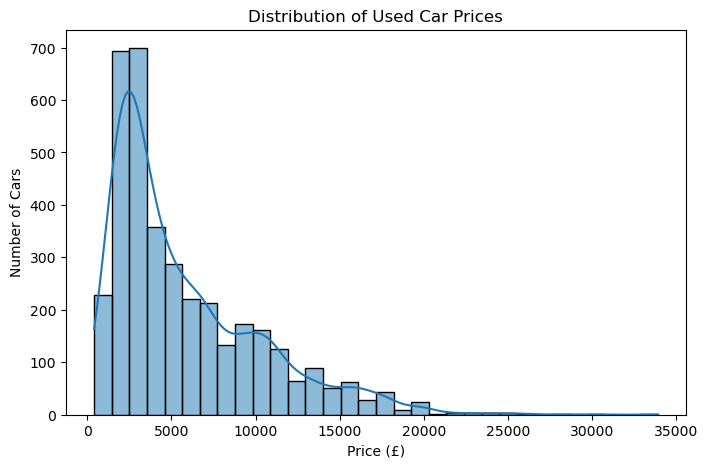

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=32, kde=True)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Number of Cars')
plt.show()

### Observation

This histogram describes the distribution of used car prices.

From the histogram, I can observe that there is strong positive skew, with most cars sold in this dataset costing between £0 to £5000, with the highest number of cars (around 1400 combined) being sold around £1000 to £4000 based on the peaks. After which, there is a steady gradual decline in the number of cars sold past £5000, with some high-priced outliers costing more than around £20,000 up to £35,000.

### Business Rationale

This is expected performance in real-world second-hand car markets. Globally, drivers are solely seeking a vehicle with the lowest prices when purchasing second-hand. In the UK, a new saloon car would cost above £10,000 - £15,000. Realistically, unless the vehicle is a luxury model costing multiple times that price brand new, drivers would not want to spend that much on an affordable automobile. 

The high turnover rate for cheaper vehicles between £1000 - £5000 is also expected (the median of the graph), since affordable cars are highly sought after in an economy where buying brand new vehicles may be too much of a financial burden for many drivers.

### ML Implications

Because there is a very strong positive skew, with the majority of listings priced between £1500 - £5000 & a sparse right tail up to £35,000, standard linear regression models are not the best choice here due to thier high sensitivity towards skewed results. MSE & RMSE penalizes large errors like the few expensive cars priced past £20,000, which leads the model to underperform on the majority of low/mid-ranged car listings.

Tree-based algorithms like Random Forest & Gradient Boosting are preferred in this scenario, as they are more robust to skewed distributions with extreme outliers due to thier rank-based splits.

### 2.4.2 Understanding Distribution of Other Features - Histograms

<function matplotlib.pyplot.show(close=None, block=None)>

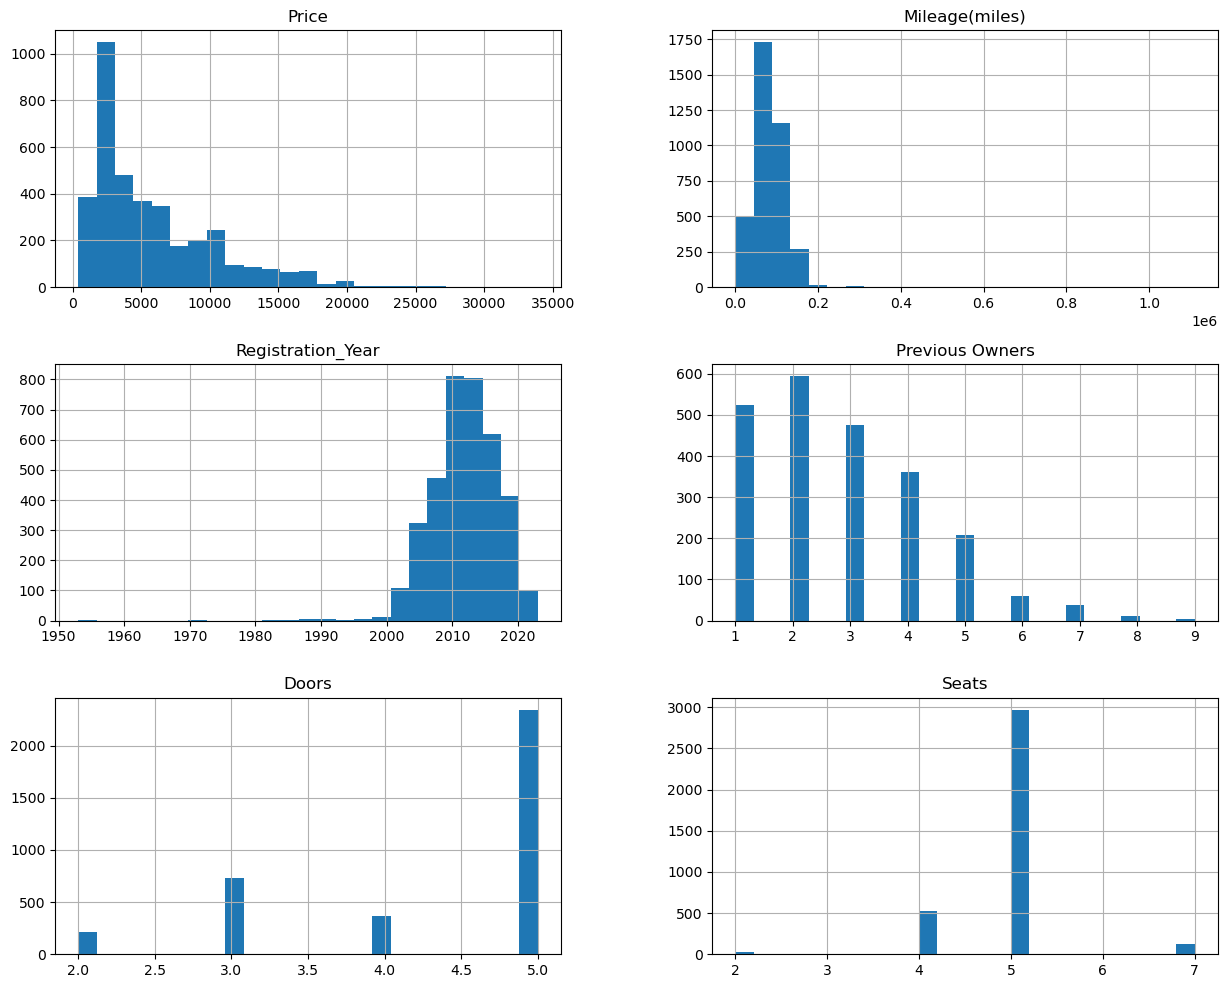

In [10]:
df.hist(figsize=(15, 12), bins = 25)
plt.show

## Prices - Positive skew. Mentioned below
## Mileage - Positive skew. 
## Previous owners - Slight positive skew

### Targeted Continuous Feature - Price

Mentioned above in 2.4.1.

### Targeted Continuous Feature - Mileage(Miles)
#### Observation

Extremely strong positively skewed. Most cars in the listings have clocked mileage under around 200,000 miles, with very few & spread out outliers clocking in past 200,000 miles & an extreme outlier clocking in more than 1,000,000 miles.

#### Business Rationale

Most vehicles still operable today often are less than 2 decades old with a realistically modest mileage count in service. High mileage vehicles are more prone to mechanical issues, and are usually scrapped once maintainance is not economically feasible anymore. This makes high mileage vehicles like the vehicle with 1,000,000 miles extremely rare.

#### ML Implications

Standard models will be highly distorted by extreme outliers, like vehicles with more than 500,000 miles clocked. Possible solution would be to cap extreme outliers during data cleaning.

### Targeted Continuous Feature - Year of Registration
#### Observation

Heavily negatively skewed. Most cars listed in this dataset were registered between around 2005 to 2015, with an extreme outlier vintage vehicle registered in 1953.

#### Business Rationale

The used market in developed countries worldwide including Singapore & the UK comprises mainly of cars that are between 5-20 years old. An economical car that is more than 20 years old would be rare, since mechanical issues, legal certificates/regulations issues would be commonplace for suc vehicles.

#### ML Implications

During feature engineering, a possible alternative would be to convert raw year values into a continuous feature to allow for improved interpretability with linear-based models.

### Discrete Features - Previous Owners
#### Observation

Positively skewed distribution, with most vehicle listings having 1 to 3 previous owners, gradually tapering off up to 9 previous owners.

#### Business Rationale

Older vehicles are more likely to have more previous owners than newer ones as they gradually age, which often results in significant drops in value.

#### ML Implications

This would be acceptable data for a standard regression model, as there are no extreme outliers present due to its gradual ordinal progression.



### 2.4.3 Features (Numeric) vs Target (Price) Relationships - Scatter Plots


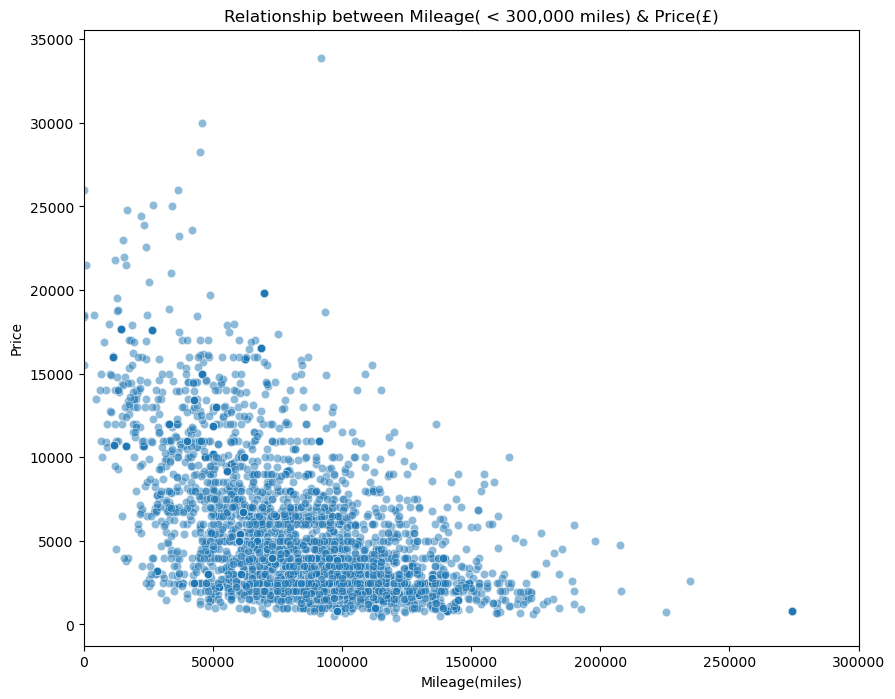

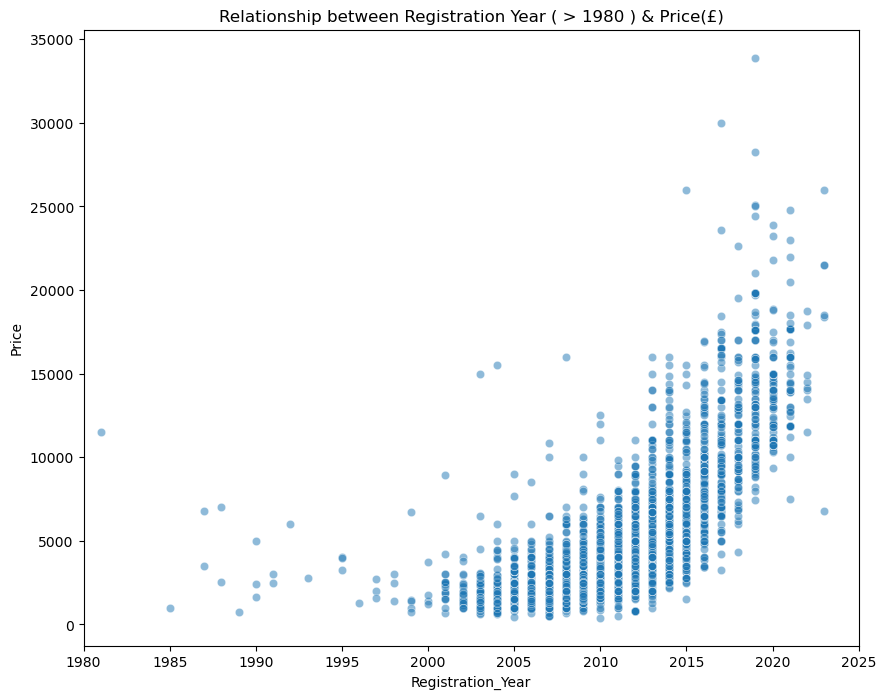

In [11]:
## Identify relationships between numerical features on the X-axis () agaisnt our target price on the Y-axis ()

## Mileage - Scatter ( limited to 300k miles due to  1.1m miles outlier )
plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Mileage(miles)', y = 'Price', alpha = 0.5, data = df)
plt.xlim(0,300000)
plt.title("Relationship between Mileage( < 300,000 miles) & Price(£)")
plt.show()

## Registration Year - Scatter
plt.figure(figsize = (10,8))
sns.scatterplot(x = 'Registration_Year', y = 'Price', alpha = 0.5, data = df)
plt.xlim(1980, 2025)
plt.title("Relationship between Registration Year ( > 1980 ) & Price(£)")
plt.show()


### Mileage(Miles) - Scatter Plot (Limited < 300,000 miles)
#### Observation

As mentioned earlier in 2.4.1/2, there was an extreme outlier of around 1.1 million miles clocked which severely compressed the majority of the dataset into a narrow band between 0 and 300,000 miles.

By omitting the outliers by limiting the plot, we can see a non-linear moderate negative correlation. There is a sharp drop in vehicle value as mileage creeps up to about 50,000 miles, afterwards, a visible trend can be seen where the value of vehicles gradually decreases until it flattens till about 200,000 miles.

#### Business Rationale

This can be seen in many instances in real-life. A car that has been in service for more time & distance on the road tend to have parts that are more worn out than a brand new counterpart due to general wear & tear. A vehicle that requires more servicing or maintanence upkeep tends to cost lesser upfront due to these highly probable, additional maintanence costs.

#### ML Implications

The extreme outliers like the 1.1 million mileage clocked vehicle must be omitted during data cleaning as it will most likely aggressively skew feature scaling during model training.

Standard forms of linear regression may underfit this feature as the relationship shown in the scatter plot highlights a non-linear trend. Tree-based models like Random Forest would be more suited in this scenario.

### Registration Year - Scatter Plot (Limited > 1980 Year)
#### Observation

There were extreme outliers for registration year, spanning from 1953 to the late 1970s. This similarly caused the majority of the listings to be highly compressed into a small cluster of dots. 

Omission of any vehicle registered before the year 1980 allows a clear non-linear positive correlation to be visible. Prices of vehicles registered from year 2000 to about 2013 shows a minute gradual upward trend, while vehicles registered from 2014 to 2023 show a sharp exponential rise in prices.

#### Business Rationale

As mentioned, vehicles that are decades old tend to exhibit signs of major wear & tear, and may often be in poorer condition than a car that is just a few years old, decreasing its value. A vehicle that requires more servicing or maintanence upkeep tends to be worth less due to these highly probable, additional maintanence costs.

#### ML Implications

Outliers like the 1953 vintage vehicle should not be included during model training as it will most likely skew feature scaling & be detrimental to our results.

Standard forms of linear regression may underfit this feature as the relationship shown in the scatter plot highlights a non-linear trend. Tree-based models like Random Forest would be more suited in this scenario.

### 2.4.4 Features (Categorical) vs Target (Price) Relationships - Box Plots

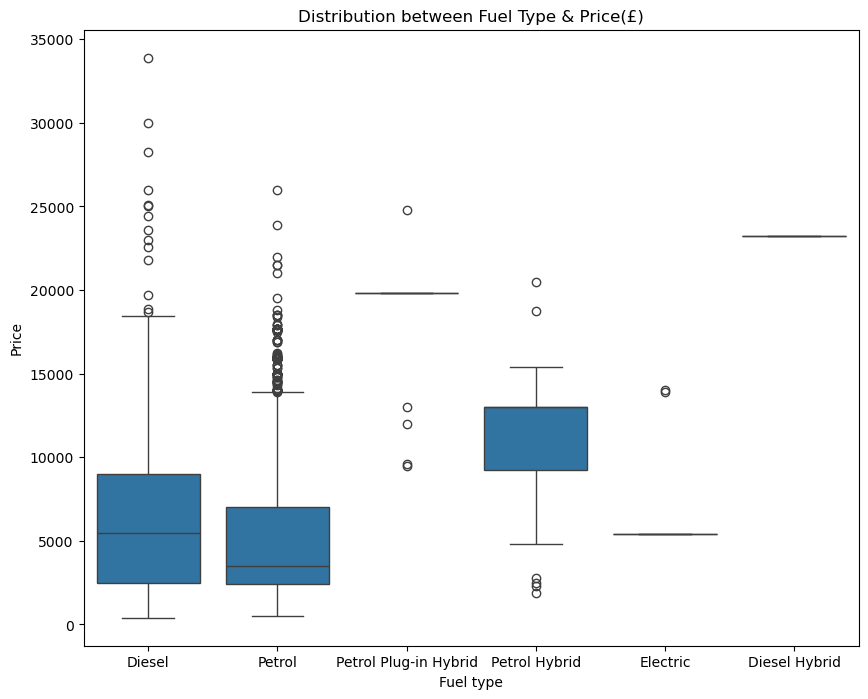

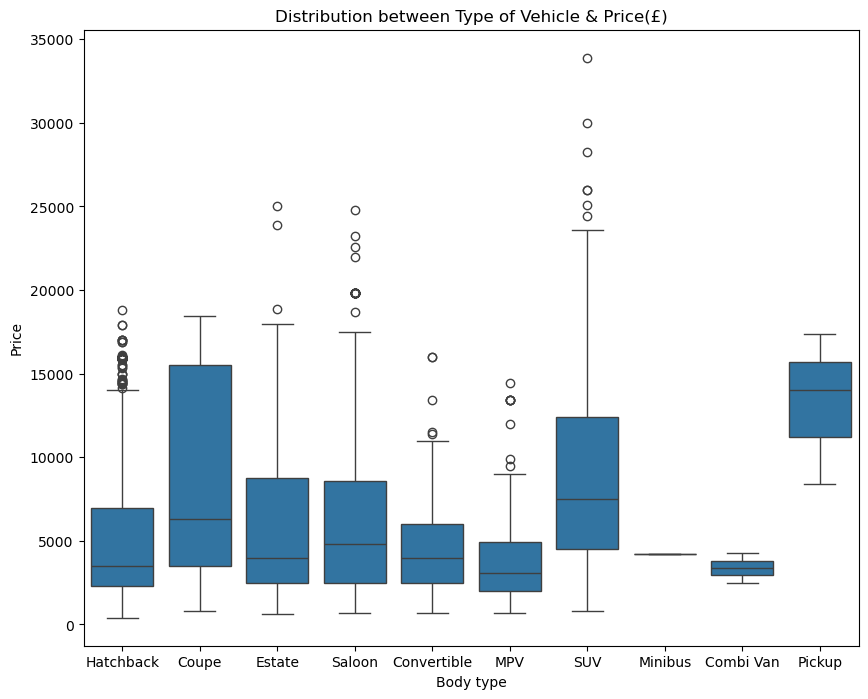

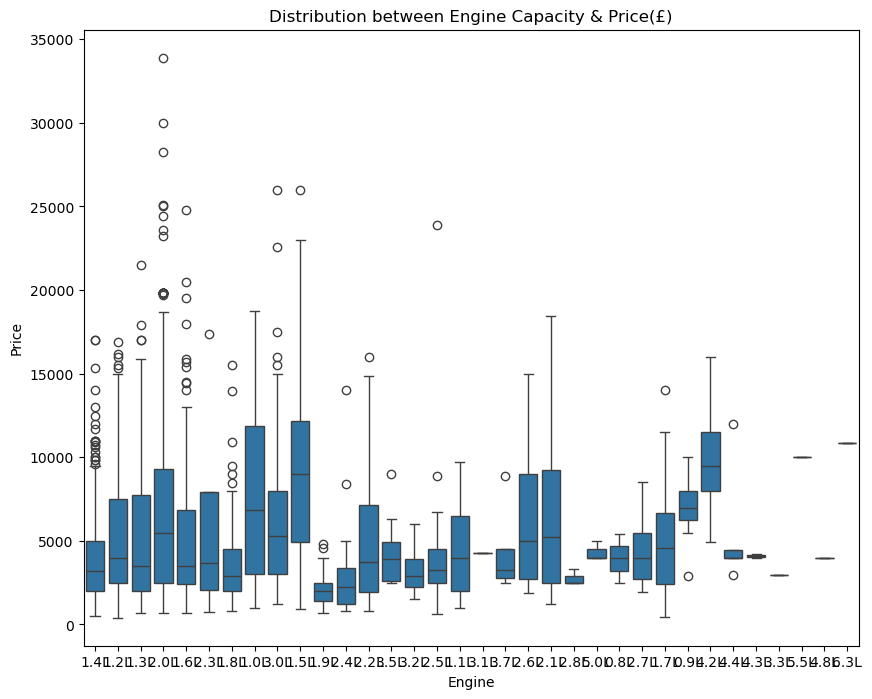

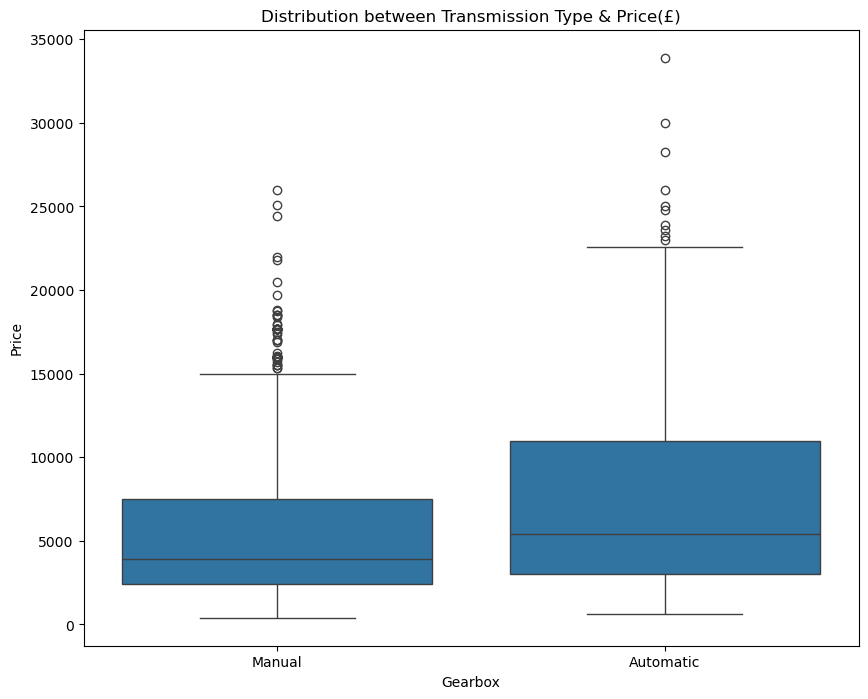

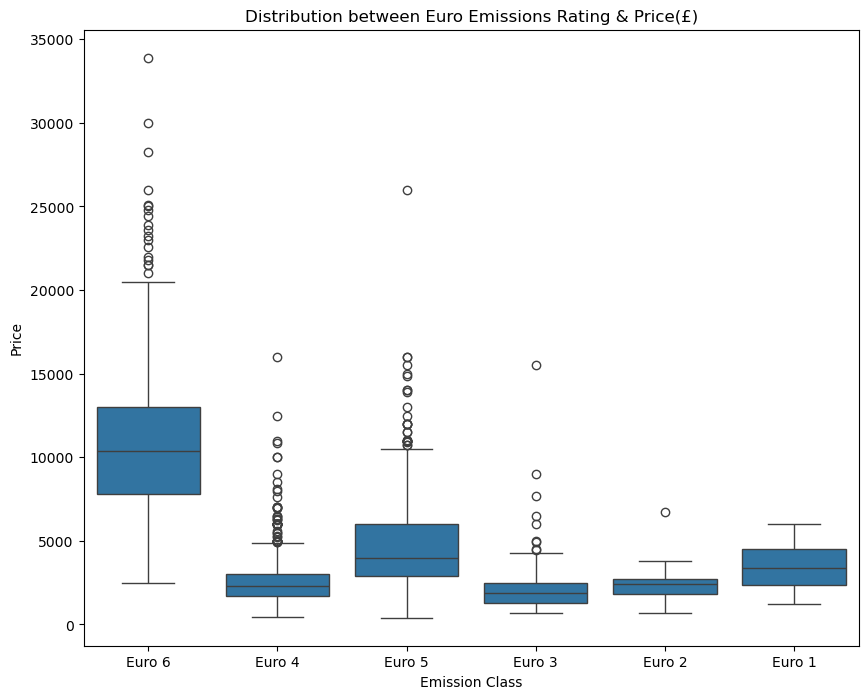

In [12]:
## Fuel Type (Diesel/Petrol/PHEV/Electric) - Box
plt.figure(figsize = (10,8))
sns.boxplot(x = 'Fuel type', y = 'Price', data = df)
plt.title("Distribution between Fuel Type & Price(£)")
plt.show()

## Type of Vehicle (e.g. Hatchback/Saloon/Estate) - Box
plt.figure(figsize = (10,8))
sns.boxplot(x = 'Body type', y = 'Price', data = df)
plt.title("Distribution between Type of Vehicle & Price(£)")
plt.show()

## Engine Capacity - Box
plt.figure(figsize = (10,8))
sns.boxplot(x = 'Engine', y = 'Price', data = df)
plt.title("Distribution between Engine Capacity & Price(£)")
plt.show()

## Transmission - Box
plt.figure(figsize = (10,8))
sns.boxplot(x = 'Gearbox', y = 'Price', data = df)
plt.title("Distribution between Transmission Type & Price(£)")
plt.show()

## Emissions - Box
plt.figure(figsize = (10,8))
sns.boxplot(x = 'Emission Class', y = 'Price', data = df)
plt.title("Distribution between Euro Emissions Rating & Price(£)")
plt.show()

### Fuel Type - Box Plot
#### Observation

Petrol-powered vehicles tend to be the cheapest compared to diesel-based vehicles & Petrol-Hybrid vehicles, having a median price of around £4000, diesel around £6000 average, petrol hybrid's lower quartile price being higher than Diesel/Petrol's upper quartile prices.

Petrol Plug-In Hybrids (PHEV), Electric & Diesel Hybrids categories are represented by flat lines or single points, partly due to thier lack of samples in the dataset.

#### Business Rationale

Petrol & Diesel powered vehicles have been the standard 2 options since the inception of the modern automobile, being the most ubiquitous. Hybrid, PHEV, Electric vehicles are relatively new technologies that were only introduced 20-30 years ago, and thier widespread adoption is not yet comparable to pure gasoline based vehicles leading to thier high manufacturing costs/retail prices.

#### ML Implications

Highly niche categories like PHEV, Diesel Hybrids & Petrol Hybrids vehicles incur a large class imbalance, due to thier low sample sizes in this dataset. A possible remedy would be to group low sample count categories into a seperate "Other" category to prevent the creation of dummy columns during OHE.

Electric Vehicles also has a miniscule sample size. Omission is neccesary to keep comparison between fuel injected vehicles fair, since they do not require Euro Emissions ratings, and consists of only 1 model.

### Type of Vehicles - Box Plot
#### Observation

Pickups generally carry the highest price premiums out of all vehicle types with a median calue just below £15000. SUVs & Coupes follow suit with moderately higher medians of around £6000 - £8000 compared to more common vehicle body types like Hatchbacks, Estates, Saloons, Convertibles, MPVs which all have median values below £5000.

#### Business Rationale

SUVs & Coupes are usually marketed as premium models of most car manufacturers due to thier improved utility or performance. Saloons, Hatchbacks, & MPVs tend to be more readily available as they are marketed for everyday use & commuting generally.

#### ML Implications

The body type of vehicles predicts baseline prices relatively well as they reflect realistic expectations of business models globally. However, categories like minibuses & combi vans should be excluded during model training as they do not have an adequate sample size, which leads to thier little or absent box spread.

### Engine Capacity - Box Plot
#### Observation

The X-axis is cluttered with multiple text label for each decimal of a litre (2.0L, 2.4L, 2.6L). Larger engines generally command a higher average price (above 2.6L) compared to more economical engines (1.0L, 1,4L).

#### Business Rationale

Larger engines are usually used for high performance or luxury models of cars, which requires more power, like sports cars, large SUVs. These generally carry a hefty premium compared to more economical cars like hatchbacks or compacts.

#### ML Implications

Curse of dimensionality is highly probable. Engine capacities which should generally be a numerical value, is being interpreted as a categorical feature because of the inclusion of a text string "L". Conversion to a continous numerical feature is neccessary.

### Transmission Type - Box Plot
#### Observation

Automatic transmission vehicles carry a sizeable premium over traditional manual gearbox transmission vehicles, as seen through a median price of around £5000 (Auto) compared to around £3500 (Manual). The most significant outliers of vehicles costing more than £25000 also belong exclusively to automatics.

#### Business Rationale

Manual transmissions have been around longer than the automatics. However, they add complexities to daily driving (clutch control, shifting). Automatics are generally priced higher as many drivers find it simpler to operate, and are also more costly to produce.

#### ML Implications

Since there are only 2 categories with ample sample sizes for each, it is highly effective & simple to implement as binary encoding for our model.

### Engine Capacity - Box Plot
#### Observation

There is a huge increase in prices for vehicles with the Euro 6 efficency rating, as seen with the high median prices around £11000, and comparatively larger upper whiskers. Vehicles with Euro 1 to Euro 5 ratings command significantly lower prices with medians below £5000.

#### Business Rationale

Euro 6 compliance is required to enter major Low Emission Zones (like London's ULEZ) without paying heavy daily penalties. Non-Euro 6 compliant cars face severe market devaluation.

#### ML Implications

Tree-based models can draw accurate distinctions between Euro 6 on its own and Euro 1 - 5 categories as a group. Missing values can be filled with an "Unknown" catergory, or imputed based on Registration Year since Euro 6 became mandatory around 2016.

### 2.4.5 Brand Frequency Chart - Bar Chart

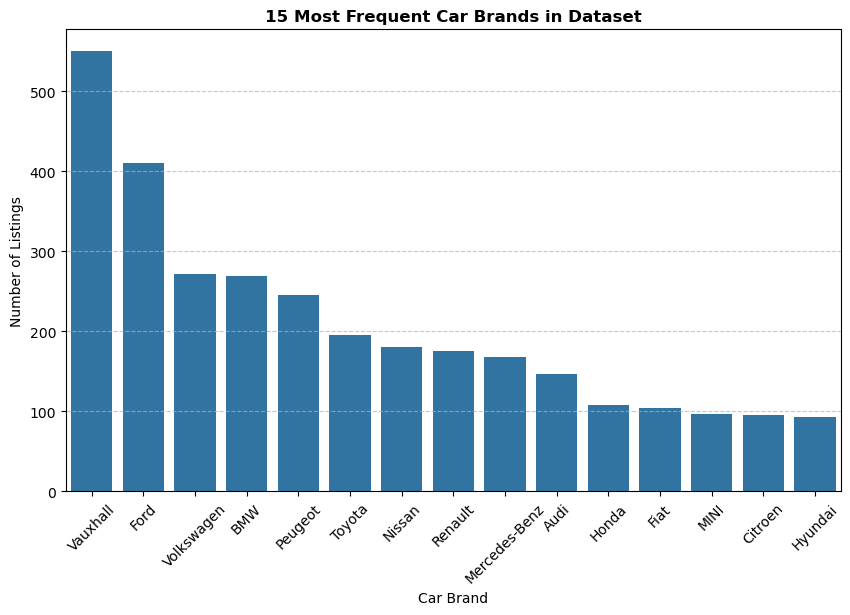

In [13]:
plt.figure(figsize=(10, 6))

popular_brands = df['Brand'].value_counts().head(15)

sns.barplot(x=popular_brands.index, y=popular_brands.values)

plt.title('15 Most Frequent Car Brands in Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Car Brand')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: Mass-market manufacturers (e.g., Ford, Vauxhall, Volkswagen) dominate listing counts, accounting for a majority of the dataset, while luxury or niche brands make up a small minority.

Business Rationale: High listing volume reflects real-world sales density; common consumer cars turn over far more frequently in the used market than high-end specialty vehicles.

Modelling Implication: Low-frequency brands appearing only a few times should be aggregated into an "Other" category during preprocessing to prevent creating dozens of sparse dummy columns during One-Hot Encoding.

### 2.3.3 Correlation vs Feature Importance - Correlation Heatmap

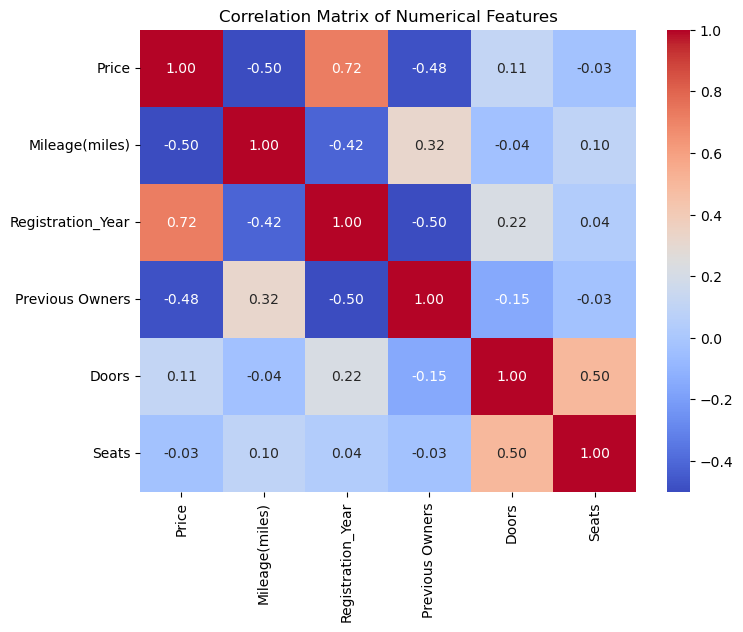

In [14]:

# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(8, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Observation: Price demonstrates a strong positive correlation with Registration_Year (newer cars cost more) and a moderate to strong negative correlation with Mileage (higher mileage cars cost less).

Business Rationale: Mechanical wear (mileage) and technological obsolescence (age) are the two primary drivers of vehicle depreciation.

Modelling Implication: Registration_Year and Mileage are essential primary inputs for target prediction. However, note potential multicollinearity between Mileage and Registration_Year (older cars naturally have higher mileage), which should be monitored when training standard linear models.

# 3. Data Preparation 


## 3.1 Data Cleaning

In [15]:
## Clean data

## 1) Drop all samples that contains null values for Previous Owners column
df = df.dropna(subset=['Previous Owners']).copy()

## 2) Omit extreme outliers that may skew results (Vehicles registered before 1980 + Mileage above 300k miles)
valid_year = df['Registration_Year'] >= 1980
valid_mileage = df['Mileage(miles)'] <= 300000
df = df[valid_year & valid_mileage]

## 3) Models - Group car models that have 5 or lesser samples into an "Others" group
number_of_models = df['Model'].value_counts()
low_count_models = number_of_models[number_of_models <= 5].index
df['Model'] = df['Model'].replace(low_count_models, 'Others')

## 4) Fuel Types - Group PHEV, Petrol Hybrid & Diesel Hybrids into a single "Hybrids" column
hybrid_variants = ['Diesel Hybrid', 'Petrol Hybrid', 'Petrol Plug-in Hybrid']
df['Fuel type'] = df['Model'].replace(hybrid_variants, 'Hybrids')

## 5) Vehicle Types - Group obscure vehicle body types (Minibus, Combi-Van) into an 'Others' category
obscure_body_types = ['Minibus', 'Combi Van']
df['Body type'] = df['Body type'].replace(obscure_body_types, 'Others')

## 6) Engine - Convert Engine Capacities to a numerical columns & remove 10 samples that are missing values
# Convert the column into strings for string manipulation functions access, replace 'L' with an empty space, assign 'L' as a plain character instead of a regex pattern for Pandas to process
df['Engine'] = df['Engine'].astype(str).str.replace('L','', regex = False)
# Convert text Strings in column to a numerical value (float64)
df['Engine'] = pd.to_numeric(df['Engine'])
# Drop the rows with null values for engine capacity
df = df.dropna(subset=['Engine'])

## 7) Use Imputation to fill missing values for Seats & Doors columns using Mode
# Extracts raw number of 5.0 out of Pandas Series List
df['Seats'] = df['Seats'].fillna(df['Seats'].mode()[0])
df['Doors'] = df['Doors'].fillna(df['Doors'].mode()[0])

## 8) Use Imputation for missing Emissions values based on Registration Year
# Select null values in Emission Class columns, where vehicle is registered in 2015 and later, impute it with Euro 6
null_emissions = df['Emission Class'].isna()
registered_2015 = df['Registration_Year'] >= 2015

df.loc[null_emissions & registered_2015, 'Emission Class'] = 'Euro 6'
df['Emission Class'] = df['Emission Class'].fillna('Unknown')

## 9) Service History - Replace null values in Service History with 'None'"MLDP code template.ipynb"
df['Service history'] = df['Service history'].fillna('None')

## 10) Checks
print(f"Final clean dataset shape: {df.shape}")
print(df.isna().sum())

Final clean dataset shape: (2264, 15)
title                0
Price                0
Mileage(miles)       0
Registration_Year    0
Previous Owners      0
Fuel type            0
Body type            0
Engine               0
Gearbox              0
Doors                0
Seats                0
Emission Class       0
Service history      0
Brand                0
Model                0
dtype: int64


## 3.2 Train-Test Split

In [16]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
y = df['Price']

# Drop target column from features ['Price', 'title', 'id']. 
# Ignore if columns already dropped
X = df.drop(columns=['Price', 'title', 'id'], errors='ignore')

# Convert categorical variables into numerical format (one-hot encoding)
X = pd.get_dummies(X, drop_first=True, dtype = int)

# Split dataset into training and testing sets
# Hint: test_size controls fraction of test data, random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1945
)

print(f"Features shape after encoding: {X.shape}")

Features shape after encoding: (2264, 236)


# 4. Modelling 

### 4.1 Train Model + Evaluation

In [17]:
## Initialise and train model
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

## 1) Feature Scaling - RobustScaler (Needed for Linear Regression)
## Used because of extreme outliers like high mileage counts noted in EDA
r_scaler = RobustScaler()
X_train_scaled = r_scaler.fit_transform(X_train)
X_test_scaled = r_scaler.transform(X_test)

## 2) Initialise Models
# Linear Regression
linr = LinearRegression(fit_intercept=True)

# Random Forest Regressor
rfr = RandomForestRegressor(random_state=1945)

# Gradient Boost Regressor
gbr = GradientBoostingRegressor(random_state=1945)

## 3) Model Training (With scanled X train data)
print("Training Models...")
linr.fit(X_train_scaled, y_train)
rfr.fit(X_train_scaled, y_train)
gbr.fit(X_train_scaled, y_train)

## 4) Model Predictions (on scaled X test data)
linr_y_pred = linr.predict(X_test_scaled)
rfr_y_pred = rfr.predict(X_test_scaled)
gbr_y_pred = gbr.predict(X_test_scaled)

## 5) Model Results
print("\n--- LINEAR REGRESSION RESULTS ---")
print("MAE: ", mean_absolute_error(y_test, linr_y_pred))
print("MSE: ", mean_squared_error(y_test, linr_y_pred))
print("RMSE: ", root_mean_squared_error(y_test, linr_y_pred))
print("R2:  ", r2_score(y_test, linr_y_pred))

print("\n--- RANDOM FOREST REGRESSOR RESULTS ---")
print("MAE: ", mean_absolute_error(y_test, rfr_y_pred))
print("MSE: ", mean_squared_error(y_test, rfr_y_pred))
print("RMSE: ", root_mean_squared_error(y_test, rfr_y_pred))
print("R2:  ", r2_score(y_test, rfr_y_pred))

print("\n--- GRADIENT BOOSTING REGRESSOR RESULTS ---")
print("MAE: ", mean_absolute_error(y_test, gbr_y_pred))
print("MSE: ", mean_squared_error(y_test, gbr_y_pred))
print("RMSE: ", root_mean_squared_error(y_test, gbr_y_pred))
print("R2:  ", r2_score(y_test, gbr_y_pred))

# 6) Top Performer
leaderboard = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, linr_y_pred), 
        r2_score(y_test, rfr_y_pred), 
        r2_score(y_test, gbr_y_pred)
    ]
})

print("\n--- TOP PERFORMERS ---")
# Sort from highest R2 to lowest R2
display(leaderboard.sort_values(by="R2 Score", ascending=False))

# save model 
import joblib
joblib.dump(rfr, 'UK_Car_Prices_rf_only_v1.pkl')


Training Models...

--- LINEAR REGRESSION RESULTS ---
MAE:  1323.4817508574627
MSE:  4128685.3347791657
RMSE:  2031.9166653136062
R2:   0.8390636158172992

--- RANDOM FOREST REGRESSOR RESULTS ---
MAE:  942.2974392935982
MSE:  2699943.0193024282
RMSE:  1643.1503337499062
R2:   0.8947560708088939

--- GRADIENT BOOSTING REGRESSOR RESULTS ---
MAE:  993.3293143854322
MSE:  2737656.0830504857
RMSE:  1654.5863782379226
R2:   0.8932860134846079

--- TOP PERFORMERS ---


,Model,R2 Score
1,Random Forest,0.894756
2,Gradient Boosting,0.893286
0,Linear Regression,0.839064


['UK_Car_Prices_rf_only_v1.pkl']

### MAE, MSE, RMSE - Business Model Implications
#### Mean Absolute Error (MAE)
MAE provides the exact amount that the model's prediction differs from the actual values on average, in GBP (£) for this instance. An MAE value of £942.30 (Random Forest) implies that the price predictions of the model is still within a acceptable margin of real-life market appraisals.

#### Root Mean Square Error (RMSE)
RMSE heavily penalizes extreme outliers, compared to MAE which treats all errors equally. Keeping RMSE as low as possible ensures the model avoids extreme pricing errors. For example, undervaluing a vehicle by £10,000 would incur a significant financial loss for a used car dealership. Conversely, overvaluing a vehicle by £10,000 will most definitely keep it from being sold indefinitely.

#### R2 Score
R2 values captures the percentage of price variance that the model outputs. Generally, a higher R2 value indicated that the model is more effective in identifying real-life market fluctuations like depreciation rather than through random chance.


### Model Performance - V1
#### Linear Regression - 3RD
Acheived an MAE of £1,323.48, MSE of £4,128,685.33, RMSE of £2,031.92, and an R2 Score of 83.91%.

#### Random Forest Regressor - 1ST
Acheived an MAE of £942.30, MSE of £2,699,943.02, RMSE of £1,643.15, and an R2 Score of 89.48%.

#### Gradient Boosting Regressor - 2ND
Acheived an MAE of £993.33, MSE of £2,737,656.08, RMSE of £1,654.59, and an R2 Score of 89.33%.

Tree-based models, Random Forest & Gradient Boosting performed better than the base Linear Regression model by roughly 5-6%. However, Random Forest Regressor model marginally acheived the lowest overall absolute error with an MAE of £942.30, making it the best performing model in this instance.

### Model Comparison - V1
#### Linear Regression
Although this model boasts high interpretability by forcing a straight line assumption on the data, it was the weakest performer as the value & depreciation rates of vehicles, where Registration Year & Mileage are important features. However, these features are realistically non-linear in nature, thus explaining its underperformance.

#### Random Forest
Highly robust to extreme outliers & non-linear relationships like Mileage, as it constructs many independent decision trees while averaging each tree's predictions in parallel. This model is highly suited the dynamic & non-linear valuation of used vehicles, proven by its strongest performance out of the 3 models.

#### Gradient Boosting
Unlike random forest models, it constructs decision trees while learning & correcting the previous tree's mistakes sequentially. It is still highly effective for predicting non-linear relationships, though it is more prone to overfitting on noisy data, which is why Random Forest outperforms it in this instance.

### Selected Model - Random Forest Regressor (V1)
Random Forest acheived the lowest overall prediction error, RMSE & MAE, while also obtaining the highest variance explanation, R2, of 89.48% compared to all other models.

Using its built-in feature importance measurement features, we can effectively visualise & identify which feature (specific vehicle specifications) affects the target feature, Price, the most. This can be accomplished by removing less important features which reduces the tree's complexity & final .pkl file size & will eventually be beneficial to the construction of my Streamlit web application.



## 4.2 Hyperparameter Tuning - RandomziedSearchCV (V1)

### Parameter Values
#### n_estimators
I have selected a modest increase in number of trees [150, 250, 350] compared to the stock 100 to test if a larger pool of trees would result in higher stability in price predictions.
#### max_depth
Experimented with a tree depth limit [10, 20] compared to unlimited depths. This limit may prevent the model from potential overfitting, caused by memorizing data, by forcing to learn broader pricing rules.
#### min_samples_split
Increasing the minimum samples required for a node to split from the default of 2 forces the model to be less specific with presented data, which does prevent overfitting to the training set.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Model...")

## Specific param values (limited to 3 sub values each)
param_values_rf = {
    'n_estimators' : [150, 250, 350], # How many trees in the forest
    'max_depth' : [10, 20, None], # How deep the trees can grow
    'min_samples_split' : [2, 5, 10] # Minimum samples required to split a node
    
}

## Initialise RandomSearchCV
rs_rf = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=1945),
    param_distributions = param_values_rf,
    cv = 5, # Number of cross-validation folds
    scoring = 'r2', # Scoring metric : R2, for highest R2 Score
    n_iter = 10, # Number of parameter settings sampled
    n_jobs = -1, # -1 : Use all avalailble cores
    random_state=1945
    )

## Fit search to (scaled) training data
rs_rf.fit(X_train_scaled, y_train)

# Obtain best Parameters, best Model, and Best cross-validation R2 Score
best_rs_params = rs_rf.best_params_
best_rs_rf_model = rs_rf.best_estimator_
best_cv_score = rs_rf.best_score_

print("\n--- TUNING SUCCESS ---")
print("\nBest Parameters : ", best_rs_params)
print("Best Model : ", best_rs_rf_model)
print("Best Cross-Validation R2 Score : ", best_cv_score)

# Evaluate Tuned Model based on scaled Test set
tuned_predictions = best_rs_rf_model.predict(X_test_scaled) # Prediction using the best model from Random Search agaisnt scaled test data

print("\n--- TUNED MODEL RESULTS ---")
print("\nTuned MAE ", mean_absolute_error(y_test, tuned_predictions))
print("Tuned MSE ", mean_squared_error(y_test, tuned_predictions))
print("Tuned RMSE ", root_mean_squared_error(y_test, tuned_predictions))
print("Tuned R2 ", r2_score(y_test, tuned_predictions))

# save model 
import joblib
joblib.dump(best_rs_rf_model, 'UK_Car_Prices_tuned_rs_rf_v1.pkl')


Tuning Model...

--- TUNING SUCCESS ---

Best Parameters :  {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': None}
Best Model :  RandomForestRegressor(min_samples_split=5, n_estimators=150, random_state=1945)
Best Cross-Validation R2 Score :  0.9023454393442506

--- TUNED MODEL RESULTS ---

Tuned MAE  943.347629962099
Tuned MSE  2691774.0896405983
Tuned RMSE  1640.6626983144945
Tuned R2  0.8950744961418547


['UK_Car_Prices_tuned_rs_rf_v1.pkl']

# 5. Model Evaluation - V1

### 5.1. Post-Tuning Result Comparison

#### Random Forest Regressor - Untuned
MAE = £942.30, MSE = £2,699,943.02, RMSE = £1,643.15, R2 = 89.48%
#### Random Forest Regressor - Tuned
MAE = £943.35, MSE = £2,691,774.09, RMSE = £1,640.66, R2 = 89.51%

Notably, the MAE value increased by about £1 (£942.30 to £943.35), while the RMSE value decreased by about £3 (£1,643.15 to £1,640.66), and the R2 score increased by 0.03%, from 89.48% to 89.51%. This implies that the tuned model sacrificed a miniscule amount of daily average accuracy in favour of preventing extreme outliers causing prediction errors, which makes it better for real-world deployment.

By limiting tree nodes to split only when there is at least 5 samples, the model became more conservative. As mentioned, sacrificing £1 in daily average accuracy (MAE) for a reduction in massive pricing errors by outliers (RMSE) is highly preferrable in real-life business environments. Thus, making this model more applicable for deployment.

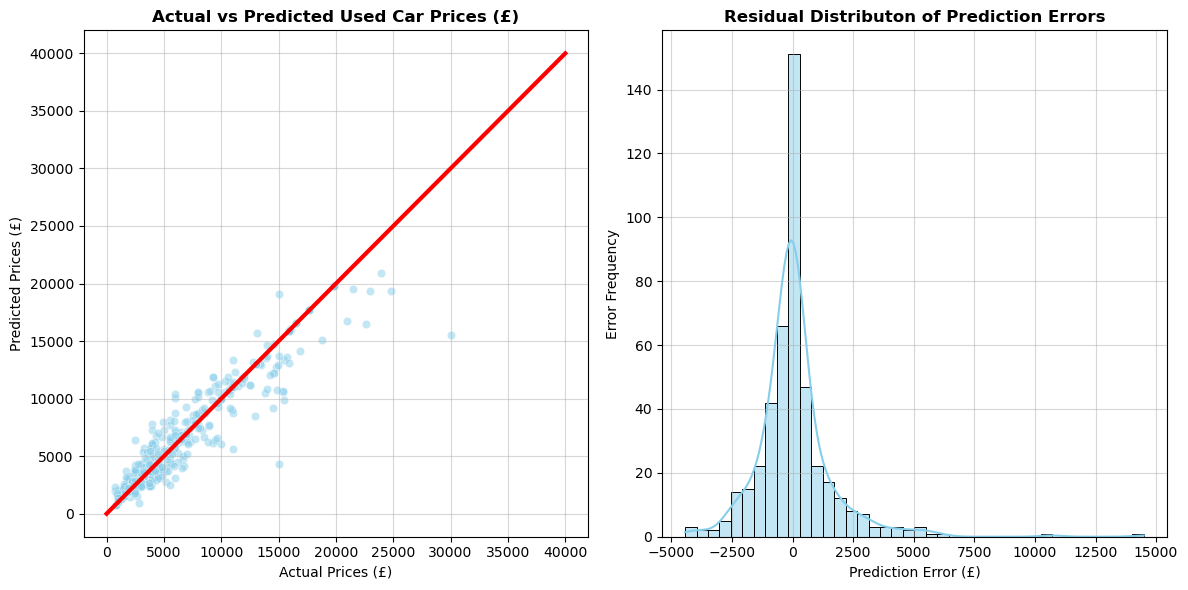

In [19]:
## Model Evaluation

## Use predictions from tuned RandomizedSearchCV model
residual_dist = y_test - tuned_predictions

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 6))

# Scatter Plot for Actual vs Predicted Prices
sns.scatterplot(x=y_test, y=tuned_predictions, alpha=0.5, color='skyblue', ax=ax1)
ax1.plot([0, 40000], [0, 40000], color='red', linewidth=3)
ax1.set_title('Actual vs Predicted Used Car Prices (£)', fontweight='bold')
ax1.set_xlabel('Actual Prices (£)')
ax1.set_ylabel('Predicted Prices (£)')
ax1.grid(True, alpha=0.5)

# Histogram - Residual Distribution (Errors)

sns.histplot(residual_dist, bins=40, kde=True, color='skyblue', ax=ax2)
ax2.set_title ('Residual Distributon of Prediction Errors', fontweight='bold')
ax2.set_xlabel('Prediction Error (£)')
ax2.set_ylabel('Error Frequency')
ax2.grid(True, alpha=0.5)

## plt.title('Feature Importance and Cumulative Importance')
plt.tight_layout()
plt.show()

### Model Evaluation - Graphs
#### Actual vs Predicted Car Prices
In this visual scatter plot graph, we can observe that the sample data points converge closely along the red diagonal line which represents perfect prediction accuracy. This shows a strong positive correlation between the relationships, which explains the high R2 score of 89.51%.

For vehicles priced below around £20,000, the model has a relatively high accuracy in its predictions. However, there is a wider spread of data at prices above £20,000, which makes sense as luxury car models sit around this high price point in general with more subjective valuation criteria.

#### Residual Distribution
In this histogram, the error frequency graph is almost symmetrical with litle to no skew, centered at £0 at its median. This indicates that the model has little bias by not systematically underpricing or overpricing vehicle prices, and with the steep curve at the median around £0, this shows that the majority of predictions have an acceptable margin of error.

In [20]:
# Predict on unseen data
# 1) Load dataset again for simulation of new/unseen data
FILE_PATH = "../datasets/used_cars_UK_ds.csv"
X_unseen = pd.read_csv(FILE_PATH)

# 2) Obtain 4 random index numbers from X_test (model did not train on test set)
unseen_test_index = X_test.sample(3, random_state=1500).index

# 3) Draw the 4 randomly selected rows from dataframe
# Drop important features like Price & title so the model can't reference the answers
unseen_test_samples = df.loc[unseen_test_index].drop(columns = ['id', 'title', 'Price'], errors = 'ignore').copy()

print("\n--- Selected Unseen Data ---\n")
display(unseen_test_samples)

# 4) Convert categorical features to numeric using OHE
X_unseen = pd.get_dummies(unseen_test_samples, drop_first=True, dtype=int)

# 5) Align columns with training data, feature selection further down(important step)
# If unseen data is missing data, fill null data with 0
X_unseen_aligned = X_unseen.reindex(columns=X_train.columns, fill_value=0)

# 6) Scale data using robust scaler
# Used because of extreme outliers like high mileage counts noted in EDA
X_unseen_scaled = r_scaler.transform(X_unseen_aligned)

# 7) Generate predictions using trained model
# .best_estimator_ to access the actual model inside the search object
unseen_test_samples['Predicted Price (£)'] = best_rs_rf_model.predict(X_unseen_scaled).round(2)

print("\n--- Predictions ---\n")
display(unseen_test_samples)


--- Selected Unseen Data ---



,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,Brand,Model
1702,119618,2015,2.0,Others,Hatchback,1.6,Manual,5.0,5.0,Euro 6,None,Citroen,Others
1162,64000,2013,2.0,Others,MPV,1.4,Manual,5.0,5.0,Euro 6,None,Fiat,Others
3337,127000,2007,3.0,Jazz,Hatchback,1.4,Manual,5.0,5.0,Euro 4,None,Honda,Jazz



--- Predictions ---



,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,Brand,Model,Predicted Price (£)
1702,119618,2015,2.0,Others,Hatchback,1.6,Manual,5.0,5.0,Euro 6,None,Citroen,Others,6561.69
1162,64000,2013,2.0,Others,MPV,1.4,Manual,5.0,5.0,Euro 6,None,Fiat,Others,7258.90
3337,127000,2007,3.0,Jazz,Hatchback,1.4,Manual,5.0,5.0,Euro 4,None,Honda,Jazz,2411.68


### Predictions on Unseen Data (X_test) V1
I used a sample of 3 used vehicles drawn at random from X_test set to replicate performance of potential real-life deployments. Scaling data using RobustScaler similarly to model training above, realignment using .reindex(), and OHE whilst omitting main target features like vehicle Price, the model was able to produce automated price estimations with no errors.

### Prediction 3 - 2007 Honda Jazz
Referring to the actual data figures for this 2007 Honda Jazz (id = 4316), it's actual listed price was £994. The predicted price was instead £2,411.68, with a variance amount of an extra £1,417.68 compared to our overall RMSE of £1,640.66. 

While such a large variance error is significant realistically, it is still within the margins of our RMSE value. This does not indicate that the model is making horrible predictions, but rather an actual limitation of the dataset itself.

Comparing to other rows that have the same make & model (2007 Honda Jazz), other vehicles are priced moderately higher than this chosen sample (id = 184, £1399, Similar Mileage). In real-world scenarios, a condition of a vehicle, such as cosmetic or mechanical damages, are decisive factors of car prices, something this dataset does not include. Since only basic technical specifications like engine capacity & mileage are listed, it would estimate prices based on a fair market average for a fully functioning 2007 Honda Jazz without any defects & issues.

Considering this particular Honda Jazz is priced below £1,000, this would indicate that there are potentially severe comesetic or engine damages to this particular vehicle. This is expected, as heavily damaged vehicles often have extremely low valuations, are often purchased for spare parts, or scrapped since it is an unappealing deal to the average consumer.

## Iterative model development - V1


,Feature,Importance,Cumulative Importance
0,Registration,0.749079,0.749079
1,Mileage(miles),0.056554,0.805633
2,Engine,0.050749,0.856382
3,Brand,0.041154,0.897536
4,Gearbox,0.035519,0.933054
5,Body type,0.018817,0.951871
6,Emission Class,0.016857,0.968727
7,Model,0.009127,0.977855
8,Fuel type,0.008907,0.986761
9,Previous Owners,0.006146,0.992907


C:\Users\Darren\AppData\Local\Temp\ipykernel_35288\1584238145.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_dt_feat_impt['Feature'], rotation=45, ha='right')


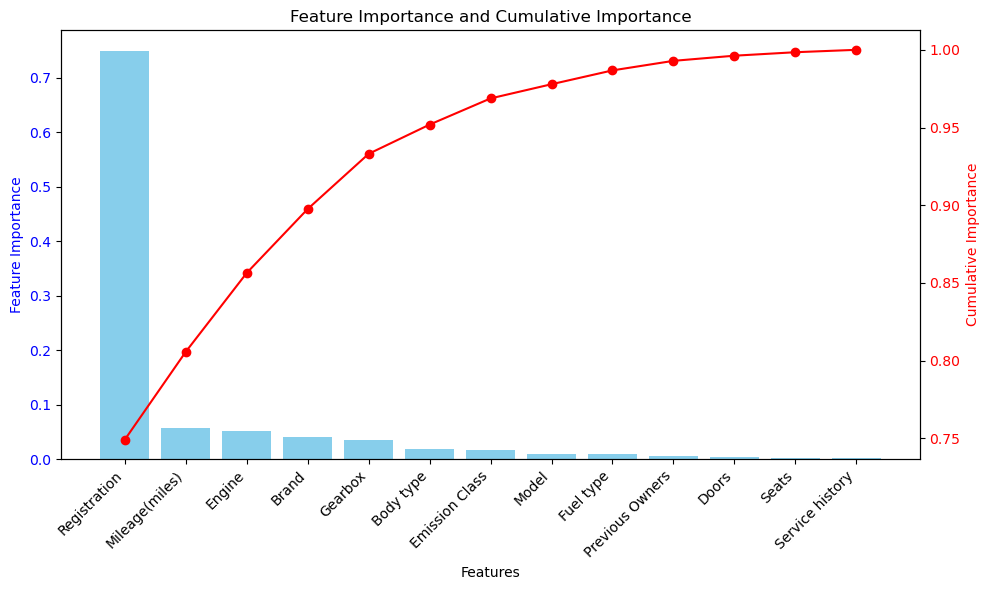

In [21]:
## Further feature engineering / feature selection
## Retreive feature importance from trained model
df_dt_feat_impt = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : best_rs_rf_model.feature_importances_
    })

## Keep original important OHE features for further filtering below
original_impt_features = df_dt_feat_impt.copy()

## Obtain original feature from OHE feature names
df_dt_feat_impt['Feature'] = df_dt_feat_impt['Feature'].str.rsplit('_', n=1).str[0]
df_dt_feat_impt = df_dt_feat_impt.groupby('Feature')['Importance'].sum().sort_values(ascending=False).reset_index()  

## Calculate cumulative importance
df_dt_feat_impt['Cumulative Importance'] = df_dt_feat_impt['Importance'].cumsum()

display(df_dt_feat_impt)

## Plot feature importance and cumulative importance

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for feature importance

ax1.bar(df_dt_feat_impt['Feature'], df_dt_feat_impt['Importance'], color='skyblue')
ax1.set_xlabel('Features')
ax1.set_ylabel('Feature Importance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(df_dt_feat_impt['Feature'], rotation=45, ha='right')

# Line chart for cumulative importance

ax2 = ax1.twinx()
ax2.plot(df_dt_feat_impt['Feature'], df_dt_feat_impt['Cumulative Importance'], color='red', marker='o')
ax2.set_ylabel('Cumulative Importance', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Feature Importance and Cumulative Importance')
plt.tight_layout()
plt.show()

### Feature Selection & Further Training - V1

In [ ]:
## 1) Feature Selection - Custom Limit.
# Keep any column that has higher than 1% importance
limit = 0.01
new_impt_features = original_impt_features[original_impt_features['Importance'] >= limit]['Feature'].tolist()

print(f"Updated Features to Keep: {(new_impt_features)}")

## 2) Refine original train/test sets BEFORE RobustScaling
X_train_refined = X_train[new_impt_features]
X_test_refined = X_test[new_impt_features]

## 3) Scale refined dataset with RobustScaler
r_scaler_final = RobustScaler()
X_train_refined_scaled = r_scaler.fit_transform(X_train_refined)
X_test_refined_scaled = r_scaler.transform(X_test_refined)

## 4) Final training on refined, smaller dataset
# Copy exact hyperparameter settings from model tuning section. No need to run RandomizedsearchCV again
best_rs_rf_model_final = best_rs_rf_model.__class__(**best_rs_rf_model.get_params())
best_rs_rf_model_final.fit(X_train_refined_scaled, y_train)

## 5) Final Evaluation
final_predictions = best_rs_rf_model_final.predict(X_test_refined_scaled)

print("\n--- FINAL STREAMLINED MODEL PERFORMANCE ---")
print(f"Final MAE:  £{mean_absolute_error(y_test, final_predictions):.2f}")
print(f"Final RMSE: £{np.sqrt(mean_squared_error(y_test, final_predictions)):.2f}")
print(f"Final R2:   {r2_score(y_test, final_predictions):.4f}")

## Write file
joblib.dump(best_rs_rf_model_final, 'UK_Car_Prices_FINAL_rs_rf_v1.pkl')
joblib.dump(r_scaler_final, 'RobustScaler_FINAL_rfr_v1.pkl')
joblib.dump(new_impt_features, 'feature_columns_FINAL_v1.pkl')


Updated Features to Keep: ['Mileage(miles)', 'Registration_Year', 'Engine', 'Gearbox_Manual', 'Emission Class_Euro 6']

--- FINAL STREAMLINED MODEL PERFORMANCE ---
Final MAE:  £1110.00
Final RMSE: £1797.83
Final R2:   0.8740


['feature_columns_FINAL_v3.pkl']

### Post Feature Selection Model Evaluation
#### Tuned Model - Pre-Feature Selection
MAE = £943.35, RMSE = £1,640.66, R2 = 89.51%
#### Final Model - Post-Feature Selection
MAE = £1,110.00, RMSE = £1,797.83 R2 = 87.40%

